**Main idea.** Keep the physics you trust, use a flexible parameterization — here, a small neural network — for the closure you do not know well, and fit it by differentiating *through* the ice-flow solver.


In [1]:
import jax, jax.numpy as jnp, numpy as np
import diffrax as dfx, equinox as eqx, optax, optimistix as optx
import matplotlib.pyplot as plt
import time

jax.config.update("jax_enable_x64", True)   # ice flow is stiff -> use 64-bit floats
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
print("jax", jax.__version__, "| diffrax", dfx.__version__, "|", jax.devices())

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


jax 0.10.2 | diffrax 0.7.2 | [CpuDevice(id=0)]


## 1 · Why universal differential equations?

Two ways to model a glacier, each with strengths and limitations:

**Physics-based models**

- Built from conservation laws and interpretable assumptions.
- Often extrapolate better when those assumptions are appropriate, but predictions can be limited by uncertain parameters and empirical closures.

**Data-driven models**

- Flexible and able to learn patterns from observations.
- Often data-hungry, and extrapolation depends strongly on the training distribution and the model's inductive bias.

A **Universal Differential Equation (UDE)** combines these ideas: keep the trusted structure and replace *only the uncertain closure* with a learnable function $\mathcal{U}_\theta$ (a small neural network):

$$\frac{du}{dt} = f\big(u, t,\; \mathcal{U}_\theta(u,t)\big).$$

We fit $\theta$ so the *solution* matches observations. Because we infer a whole **function**, this is an example of **functional inversion** (Rackauckas et al., 2020; Bolibar et al., 2023).

::: {.callout-note}
### 1.1 The key idea

- We keep the conservation laws (mass, momentum) and learn selected closures or parameterizations: for example, how ice deforms, how it slides, or how mass balance depends on climate.
- The neural network is not the whole glacier model. It is a learnable component inside the model.
:::


## 2 · Example UDE: SIA with learned $A(T)$

* Suppose we trust the mass-conservation/SIA structure, but do not know how to specify the rate factor $A$.
* We expect $A$ to depend on ice temperature and material state, but the relationship is uncertain.

$$\frac{\partial H}{\partial t} = \dot b + \frac{\partial}{\partial x}\!\left(D\,\frac{\partial S}{\partial x}\right),
\qquad D = \Gamma\,H^{\,n+2}\Big|\partial_x S\Big|^{\,n-1},
\qquad \Gamma = \frac{2A}{n+2}(\rho g)^n,$$

with $S = b + H$ (surface), $b$ bedrock, and $\dot b$ climatic mass balance.

The observable surface velocity comes from the same SIA physics: $\,u_s = \tfrac{2A}{n+1}(\rho g)^n H^{\,n+1}\big|\partial_x S\big|^{\,n}.$

The split between what we prescribe and what we learn *is* the UDE:

| Prescribed structure | Learned closure |
|---|---|
| Mass conservation + SIA | **Glen's creep parameter $A$**: ice "softness" |

::: {.callout-note}
### 2.1 Our target
$A$ depends on temperature, water content, fabric, and other material properties (Cuffey & Paterson, 2010). In simple models it is often treated as a tuned constant or prescribed parameter. Here we learn a temperature-dependent version, $A(T)$.
:::


## 3 · ML reminders (the parts we lean on)

You already know these; two quick reminders, then the one new wrinkle:

- **A neural network is a flexible parametric function** $\mathcal{U}_\theta$ with trainable parameters $\theta$. With enough capacity, it can approximate broad classes of continuous functions on bounded domains.
- **Training = minimizing a loss $L(\theta)$ by gradient descent** ($\theta \leftarrow \theta - \eta\,\nabla_\theta L$; Adam is a more adaptive version).

The new wrinkle in a UDE: the quantity we differentiate is the output of an **ODE / PDE solver**.


## 4 · The UDE idea: training as differential-equation-constrained optimization

This is the conceptual heart of the lecture — the bridge from ordinary ML to physics.

**Ordinary ML** minimizes a loss directly over the network's prediction:

$$\min_\theta\; L(\mathcal{U}_\theta).$$

**A UDE** minimizes a similar misfit, but the prediction is defined *through the solution of a differential equation*. The loss depends on the state $u$, and $u$ is constrained by the model equations:

$$\min_\theta\; L(u,\theta)\quad\text{subject to}\quad \frac{du}{dt}=f\big(u,t,\mathcal{U}_\theta(u,t)\big).$$

That single "subject to" is the main structural difference. In computation, the PDE is discretized and the solver returns a numerical state satisfying the discrete equations to solver tolerance. The optimizer can change the closure, but it cannot freely choose a state that bypasses the model.

| | Pure physics | **UDE (grey box)** | Neural ODE | Pure ML |
|---|---|---|---|---|
| RHS | prescribed $f$ | **prescribed structure + learned $\mathcal{U}_\theta$** | mostly or entirely learned | no DE structure |
| Data needed | calibration / validation | **closure-level data signal** | trajectory data | often data-rich settings |
| Extrapolation / interpretability | often strong if assumptions hold | **improved by retained physics** | depends on learned dynamics | often limited outside training data |

To take a gradient step we need $\nabla_\theta L$, but $L$ depends on $\theta$ *through the constrained solution* $u$. Differentiating through that constraint is the same adjoint/reverse-mode idea used in inverse modelling (MacAyeal, 1993). In differentiable programming, `jax.grad` can trace the numerical solve and compute the required vector-Jacobian products without us deriving them by hand.

### Hard vs. soft constraints: the contrast with PINNs

You have likely already met **PINNs**, which represent the *solution* with a network and add the PDE residual to the loss as a penalty. In the language above, that is a **penalty method**: the physics is encouraged by the objective, so it acts as a **soft constraint**.

$$\text{PINN:}\qquad \min_\phi\; L_{\text{data}}(u_\phi)\;+\;\lambda\,\big\lVert\,\mathcal{R}[u_\phi]\,\big\rVert^2 .$$

A **UDE** instead generates the state with an embedded solver. The resulting state satisfies the discretized equations, within the chosen model, discretization, and solver tolerance.

$$\text{UDE:}\qquad \min_\theta\; L_{\text{data}}(u,\theta)\quad\text{subject to}\quad \tfrac{du}{dt}=f\big(u,t,\mathcal{U}_\theta\big).$$

| | PINN (soft constraint) | UDE (solver-constrained) |
|---|---|---|
| Network represents | the solution $u_\phi$ | the unknown closure $\mathcal{U}_\theta$ in the RHS |
| PDE enters via | a residual penalty $\lambda\lVert\mathcal{R}[u_\phi]\rVert^2$ | an embedded equation solver |
| Physics satisfied | approximately, depending on optimization and penalty weight | by the numerical solver, to discretization and solver tolerance |
| Conservation laws | encouraged by the loss | built into the solver/discretization |

*SINDy* (sparse discovery of terms) and *Neural ODEs* (learn the entire RHS) are the other neighbors; a UDE sits in between: keep the trusted operator, learn only the missing closure. The `AD_and_adjoints_concepts` companion makes the adjoint connection precise.


## 5 · Worked example: recovering Glen's creep parameter $A(T)$

::: {.callout-important}
### The inverse problem
Suppose we trust the SIA model but do not know how the rate factor $A$ varies with temperature. We can observe surface velocities. Can we learn $A(T)$ from those velocities, *through* the ice-flow equation?
:::

- This is the similar experiment of Bolibar et al. (2023) so we know the truth and can check the result. 

- Because the same model family generates and fits the data, this isolates the closure-learning mechanism; real applications also include structural model error and additional identifiability challenges.

1. Invent a *hidden* law $A_{\text{true}}(T)$ (warmer $\Rightarrow$ softer ice).
2. Generate "observations": glaciers at different temperatures, evolved a few decades; record surface velocities.
3. Hide $A_{\text{true}}$. Replace $A$ with a network $A_\theta(T)$ and train it to match the velocities.
4. Compare recovered $A_\theta(T)$ to the truth, which was used only for evaluation.

### 5.1 The known physics: the SIA flowline model


In [2]:
# --- constants (SI units, time in YEARS) -----------------------------------
RHO, G = 900.0, 9.81                 # ice density [kg/m^3], gravity [m/s^2]
N_GLEN = 3.0                         # Glen exponent (assumed known)
A_FLOOR, A_CEIL = 1e-18, 4e-16       # physical band for A [Pa^-3 a^-1]

# --- finite-volume flowline: NX cells (control volumes) of width dx ---------
L, NX = 30_000.0, 40
dx = L / NX
x = (jnp.arange(NX) + 0.5) * dx      # cell-CENTER positions [m]
bed = 2800.0 - 0.04 * x              # bedrock at cell centers [m]
ELA, BETA, CAP = 1800.0, 0.004, 0.8  # equilibrium-line altitude, MB gradient, max accumulation

def mass_balance(S):
    "Altitude-dependent surface mass balance [m ice / a]."
    return jnp.clip(BETA * (S - ELA), None, CAP)

In [3]:
def sia_rhs(t, H, A):
    '''dH/dt for the SIA flowline.
    Known physics:  dH/dt = b_dot + d/dx( D dS/dx ),  D = (2A/(n+2))(rho g)^n H^(n+2) |dS/dx|^(n-1).
    Fluxes are evaluated on cell faces; `A` is the creep parameter we later replace with a network.'''
    A = jnp.clip(A, A_FLOOR, A_CEIL)
    H = jnp.clip(H, 0.0)
    S = bed + H                                       # surface elevation at cell centers
    dSdx   = (S[1:] - S[:-1]) / dx                    # surface slope on faces
    H_face = 0.5 * (H[1:] + H[:-1])                   # thickness on faces
    Gamma  = 2.0 * A / (N_GLEN + 2.0) * (RHO * G) ** N_GLEN
    D      = Gamma * H_face ** (N_GLEN + 2.0) * jnp.abs(dSdx) ** (N_GLEN - 1.0)
    q_int  = -D * dSdx                                # ice flux through faces
    q   = jnp.concatenate([jnp.zeros(1), q_int, jnp.zeros(1)])   # no flux at divide & terminus
    div = -(q[1:] - q[:-1]) / dx
    # can't melt absent ice: a SMOOTH limiter (differentiable at the moving front)
    limiter = jnp.clip(H / 10.0, 0.0, 1.0)
    bdot = mass_balance(S)
    return jnp.maximum(bdot, 0.0) + jnp.minimum(bdot, 0.0) * limiter + div

::: {.callout-note}
#### Solver choice
Ice flow is stiff diffusion ($D \propto H^{n+2}$), so we integrate with a simple **implicit (backward-Euler)** scheme, which remains stable at relatively large time steps in this example. Each step solves a small nonlinear system (the `root_finder`).
:::


In [4]:
# Implicit backward-Euler solver. Fixed step; each step solves a nonlinear system.
SOLVER = dfx.ImplicitEuler(root_finder=optx.Newton(rtol=1e-5, atol=1e-4, norm=optx.max_norm))
DT_YEARS = 0.5

def solve_sia(A, H0, t1):
    "Integrate the SIA forward to time t1 [years]; return final thickness."
    n = int(round(t1 / DT_YEARS))
    sol = dfx.diffeqsolve(
        dfx.ODETerm(sia_rhs), SOLVER, t0=0.0, t1=t1, dt0=DT_YEARS, y0=H0, args=A,
        stepsize_controller=dfx.ConstantStepSize(), max_steps=n + 5,
        saveat=dfx.SaveAt(t1=True),
        adjoint=dfx.RecursiveCheckpointAdjoint(),  # checkpointed adjoint: lets jax.grad see through
    )
    return sol.ys[-1]

def surface_velocity(H, A):
    "SIA surface speed at cell centers [m/a] -- our observable."
    A = jnp.clip(A, A_FLOOR, A_CEIL); H = jnp.clip(H, 0.0); S = bed + H
    dSdx = (S[1:] - S[:-1]) / dx; H_face = 0.5 * (H[1:] + H[:-1])
    u_face = (2.0 * A / (N_GLEN + 1.0)) * (RHO * G) ** N_GLEN \
        * H_face ** (N_GLEN + 1.0) * jnp.abs(dSdx) ** N_GLEN      # speed on interior faces
    u = jnp.concatenate([jnp.zeros(1), u_face, jnp.zeros(1)])     # no-flux faces -> 0
    return 0.5 * (u[1:] + u[:-1])                                 # average faces to cell centers

### 5.2 The hidden truth and the synthetic observations

A controlled recipe, so it is clear exactly what generates the data:

1. **Spin up one shared glacier**: evolve from bare bedrock to a quasi-steady starting geometry $H_{\text{init}}$, used by all eight.
2. **Pick eight temperatures** ($-25$ to $-3$ °C) and give each its hidden softness $A_{\text{true}}(T)$, *the only thing that differs between glaciers*.
3. **Evolve each for `T_OBS` = 30 years** under the same SMB (for simplicity). Softer (warmer) ice deforms faster.
4. **Record surface velocities** $U_{\text{obs}}$: these are the training targets.

The training data are velocities only. The hidden $A_{\text{true}}(T)$ is not given to the optimizer; it is kept aside for the final check.


In [5]:
T_glaciers = jnp.linspace(-25.0, -3.0, 8)        # eight synthetic glaciers

def A_true(T):
    "HIDDEN ground-truth creep law: warmer ice -> larger A. [Pa^-3 a^-1]"
    return 1.0e-16 * jnp.exp(0.13 * (T + 10.0))

A_REF  = float(A_true(-14.0))                    # reference A, used only to spin up geometry
T_SPIN = 300.0                                   # years to build a quasi-steady start
T_OBS  = 30.0                                    # observed transient length [years]

H_init = solve_sia(A_REF, jnp.zeros(NX), T_SPIN)            # common starting geometry
A_vals = A_true(T_glaciers)
H_obs  = jax.vmap(lambda A: solve_sia(A, H_init, T_OBS))(A_vals)
U_obs  = jax.vmap(surface_velocity)(H_obs, A_vals)          # the "observations"

print(f"starting geometry: max thickness {float(H_init.max()):.0f} m")
print("observed peak velocity per glacier [m/a]:", np.round(np.array(U_obs.max(axis=1)), 1))

starting geometry: max thickness 240 m
observed peak velocity per glacier [m/a]: [ 3.8  5.2  7.4 12.7 21.4 30.7 33.8 44.4]


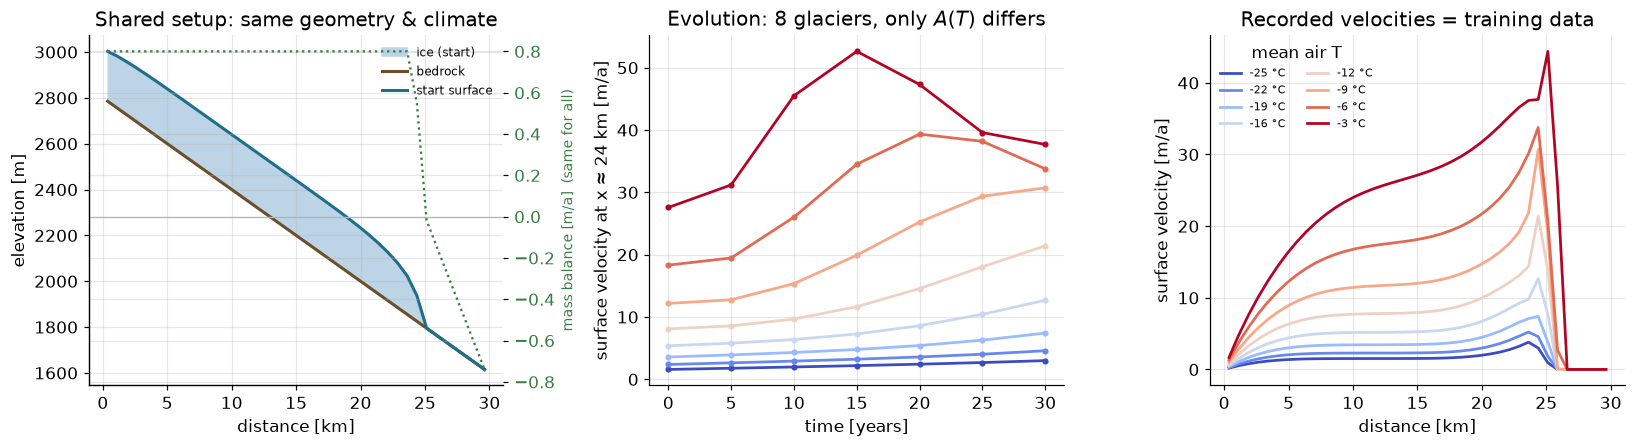

In [6]:
# Time-resolved evolution for the figure (display only -- no gradients needed here).
K, t_save = 7, jnp.linspace(0.0, T_OBS, 7)
def evolve_traj(A):
    sol = dfx.diffeqsolve(dfx.ODETerm(sia_rhs), SOLVER, t0=0.0, t1=T_OBS, dt0=DT_YEARS, y0=H_init,
                          args=A, stepsize_controller=dfx.ConstantStepSize(),
                          max_steps=int(T_OBS / DT_YEARS) + 5, saveat=dfx.SaveAt(ts=t_save))
    return sol.ys                                                        # (K, NX)
H_traj = jax.vmap(evolve_traj)(A_vals)                                   # (8, K, NX)
U_traj = jax.vmap(lambda Ht, A: jax.vmap(lambda H: surface_velocity(H, A))(Ht))(H_traj, A_vals)
ref    = int(np.argmax(np.array(U_obs).mean(axis=0)))                    # a representative fast point
uref   = np.array(U_traj[:, :, ref])                                     # (8, K) speed there over time

colors = plt.cm.coolwarm(np.linspace(0, 1, len(T_glaciers)))
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) The SHARED setup: one geometry and one climate, identical for every glacier.
ax[0].fill_between(x/1000, bed, bed + np.array(H_init), color="#bcd4e6", label="ice (start)")
ax[0].plot(x/1000, bed, color="#6b4f2a", lw=2, label="bedrock")
ax[0].plot(x/1000, bed + np.array(H_init), color="#1f6f8b", lw=2, label="start surface")
ax[0].set(xlabel="distance [km]", ylabel="elevation [m]",
          title="Shared setup: same geometry & climate")
ax[0].legend(frameon=False, fontsize=8, loc="upper right")
axb = ax[0].twinx()                                                      # the one mass-balance law
axb.plot(x/1000, np.array(mass_balance(bed + np.array(H_init))), color="#3a7d44", lw=1.5, ls=":")
axb.axhline(0.0, color="0.7", lw=0.8)
axb.set_ylabel("mass balance [m/a]  (same for all)", color="#3a7d44", fontsize=9)
axb.tick_params(axis="y", labelcolor="#3a7d44")

# (b) EVOLUTION over the 30-year transient -- the only difference between curves is A(T).
for i in range(len(T_glaciers)):
    ax[1].plot(np.array(t_save), uref[i], color=colors[i], lw=1.8, marker="o", ms=3)
ax[1].set(xlabel="time [years]", ylabel=f"surface velocity at x \u2248 {float(x[ref])/1000:.0f} km [m/a]",
          title="Evolution: 8 glaciers, only $A(T)$ differs")

# (c) The OBSERVATIONS: final velocity profiles we train on.
for i, T in enumerate(np.array(T_glaciers)):
    ax[2].plot(x/1000, np.array(U_obs[i]), color=colors[i], lw=1.8, label=f"{T:.0f} °C")
ax[2].set(xlabel="distance [km]", ylabel="surface velocity [m/a]",
          title="Recorded velocities = training data")
ax[2].legend(frameon=False, fontsize=7, title="mean air T", ncol=2)
plt.tight_layout(); plt.show()

Warmer glaciers flow faster for the same geometry in this synthetic setup: softer ice. That spread is the signal we invert.

### 5.3 The learnable closure: a neural network $A_\theta(T)$

::: {.callout-note}
#### Three useful modeling choices for the network
- **Normalize the input**: feed $(T+14)/11$ so it is $O(1)$.
- **Learn a deviation from a physics baseline**: output $A_\theta(T)=A_\mathrm{ref}\,e^{\,\mathrm{net}(T)}$, i.e. learn $\log A$ relative to a reference. This is scale-aware because $A$ spans orders of magnitude, and it keeps $A$ positive by construction.
- **Make initialization well behaved**: with the normalized input and the log-deviation form, the untrained network starts nearly flat and near $A_\mathrm{ref}$.
:::


In [7]:
class CreepNet(eqx.Module):
    "Neural network for the creep parameter:  T -> A_theta(T)."
    mlp: eqx.nn.MLP

    def __init__(self, key):
        # small on purpose: the PDE supplies strong structure, so few parameters are needed
        self.mlp = eqx.nn.MLP(in_size=1, out_size=1, width_size=10, depth=2,
                              activation=jax.nn.softplus, key=key)

    def __call__(self, T):
        z = jnp.atleast_1d((T + 14.0) / 11.0)            # normalize input to ~O(1)
        return A_REF * jnp.exp(jnp.clip(self.mlp(z)[0], -5.0, 5.0))   # learn log-deviation from A_REF

model0 = CreepNet(jax.random.PRNGKey(0))
n_par = sum(p.size for p in jax.tree_util.tree_leaves(eqx.filter(model0, eqx.is_array)))
print(f"untrained A_theta(-10 C) = {float(model0(-10.0)):.2e}   |   {n_par} trainable parameters")

untrained A_theta(-10 C) = 6.57e-17   |   141 trainable parameters


### 5.4 The loss: gradients *through* the solver

This is the constrained objective from §4 made concrete: the loss runs the **same** SIA solver with $A_\theta(T)$ and compares predicted to observed velocities. `eqx.filter_value_and_grad` differentiates the loss **through `diffeqsolve`**. With the checkpointed Diffrax adjoint used in `solve_sia`, this computes the required reverse-mode sensitivities through the discretized solver.


In [8]:
def loss_fn(model, U_obs):
    A_pred = jax.vmap(model)(T_glaciers)                              # A_theta(T) per glacier
    H_pred = jax.vmap(lambda A: solve_sia(A, H_init, T_OBS))(A_pred)  # SOLVE the PDE
    U_pred = jax.vmap(surface_velocity)(H_pred, A_pred)
    scale  = jnp.maximum(U_obs.max(axis=1, keepdims=True), 1.0)       # weigh glaciers equally
    return jnp.mean(((U_pred - U_obs) / scale) ** 2)

loss0, grads = eqx.filter_value_and_grad(loss_fn)(model0, U_obs)
print(f"initial loss = {float(loss0):.3e}   |   gradient norm = {float(optax.global_norm(grads)):.3e}")

initial loss = 5.203e-01   |   gradient norm = 3.998e+00


### 5.5 Train  (Adam + cosine-decayed learning rate + gradient clipping; ~30 s)

In [9]:
N_EPOCHS = 400
schedule = optax.cosine_decay_schedule(init_value=3e-3, decay_steps=N_EPOCHS, alpha=0.05)
optimizer = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(schedule))

model = CreepNet(jax.random.PRNGKey(0))
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

@eqx.filter_jit
def train_step(model, opt_state, U_obs):
    loss, grads = eqx.filter_value_and_grad(loss_fn)(model, U_obs)
    updates, opt_state = optimizer.update(grads, opt_state)
    return eqx.apply_updates(model, updates), opt_state, loss

history = []
t0 = time.time()
for epoch in range(N_EPOCHS):
    model, opt_state, loss = train_step(model, opt_state, U_obs)
    history.append(float(loss))
    if epoch % 50 == 0 or epoch == N_EPOCHS - 1:
        print(f"epoch {epoch:4d}   loss = {float(loss):.3e}")
print(f"\ntrained in {time.time() - t0:.1f} s")

epoch    0   loss = 5.203e-01


epoch   50   loss = 8.854e-02


epoch  100   loss = 7.703e-02


epoch  150   loss = 5.605e-02


epoch  200   loss = 1.639e-02


epoch  250   loss = 6.780e-04


epoch  300   loss = 4.998e-04


epoch  350   loss = 4.384e-04


epoch  399   loss = 4.119e-04

trained in 45.2 s


### 5.6 Did we recover the hidden closure?

Plot learned $A_\theta(T)$ against the truth withheld from training, the analogue of Figure 3 in Bolibar et al.


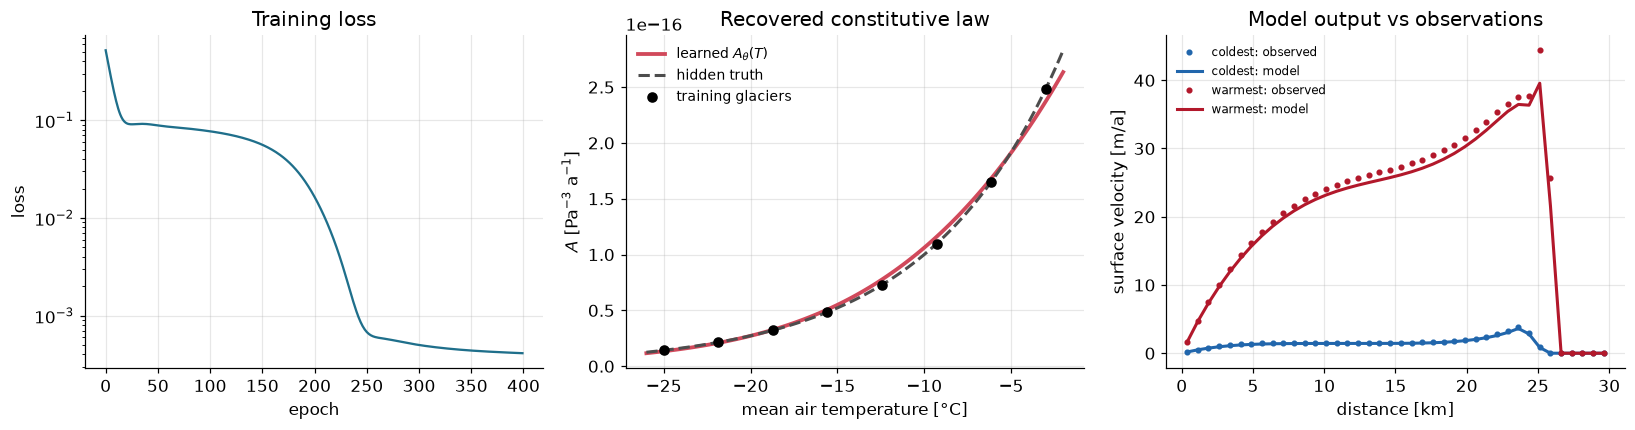

recovery error in A(T):  mean 4.1%   max 6.5%


In [10]:
A_learned = jax.vmap(model)(T_glaciers)
rel_err = np.abs(np.array((A_learned - A_vals) / A_vals))
T_dense = jnp.linspace(-26.0, -2.0, 100)

# Model output after training: predicted velocities (what we compare to observations)
H_pred = jax.vmap(lambda A: solve_sia(A, H_init, T_OBS))(A_learned)
U_pred = jax.vmap(surface_velocity)(H_pred, A_learned)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) training loss
ax[0].semilogy(history, color="#1f6f8b")
ax[0].set(xlabel="epoch", ylabel="loss", title="Training loss")

# (b) recovered constitutive law vs the hidden truth
ax[1].plot(np.array(T_dense), np.array(jax.vmap(model)(T_dense)), color="#d1495b", lw=2.5,
           label=r"learned $A_\theta(T)$")
ax[1].plot(np.array(T_dense), np.array(A_true(T_dense)), "--", color="0.3", lw=2, label="hidden truth")
ax[1].scatter(np.array(T_glaciers), np.array(A_vals), color="k", zorder=5, s=35, label="training glaciers")
ax[1].set(xlabel="mean air temperature [°C]", ylabel=r"$A$ [Pa$^{-3}$ a$^{-1}$]",
          title="Recovered constitutive law")
ax[1].legend(frameon=False, fontsize=9)

# (c) model output vs observations (the actual fit) for coldest & warmest glacier
for idx, name, c in [(0, "coldest", "#2166ac"), (len(T_glaciers) - 1, "warmest", "#b2182b")]:
    ax[2].plot(x/1000, np.array(U_obs[idx]),  "o", ms=3, color=c, label=f"{name}: observed")
    ax[2].plot(x/1000, np.array(U_pred[idx]), "-", color=c, lw=2, label=f"{name}: model")
ax[2].set(xlabel="distance [km]", ylabel="surface velocity [m/a]",
          title="Model output vs observations")
ax[2].legend(frameon=False, fontsize=8)

plt.tight_layout(); plt.show()
print(f"recovery error in A(T):  mean {rel_err.mean():.1%}   max {rel_err.max():.1%}")

Relative to a black-box fit, this gives us:

- **Interpretable closure**: $A_\theta(T)$ is a curve we can inspect and compare to lab or field knowledge.
- **Physics-constrained predictions**: predicted velocities are generated by a mass-conserving SIA solver, within the chosen discretization and tolerances.
- **Data efficiency in this example**: a handful of synthetic glaciers sufficed because the observations were informative about the closure.

### 5.7 Bonus: robustness to noise

::: {.callout-note}
#### Inductive bias from the embedded PDE
The embedded PDE acts as a strong inductive bias, which can reduce overfitting even without an explicit regularization penalty. Add 15% noise and retrain:
:::


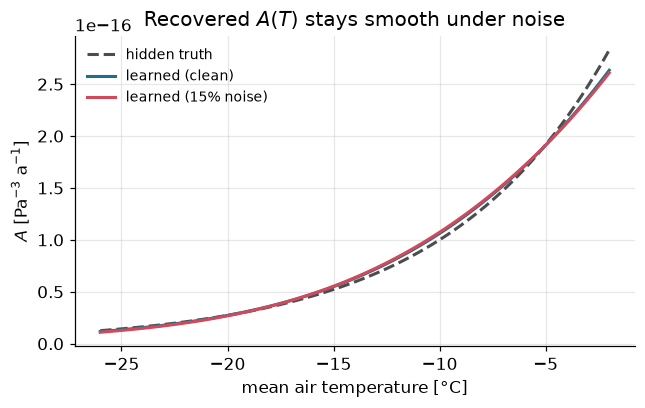

recovery error WITH 15% noise:  mean 5.4%   max 10.6%


In [11]:
U_noisy = U_obs + 0.15 * U_obs * jax.random.normal(jax.random.PRNGKey(42), U_obs.shape)
model_n = CreepNet(jax.random.PRNGKey(0))
opt_state_n = optimizer.init(eqx.filter(model_n, eqx.is_array))
for _ in range(N_EPOCHS):
    model_n, opt_state_n, _ = train_step(model_n, opt_state_n, U_noisy)

rel_n = np.abs(np.array((jax.vmap(model_n)(T_glaciers) - A_vals) / A_vals))
plt.figure(figsize=(6, 4))
plt.plot(np.array(T_dense), np.array(A_true(T_dense)), "--", color="0.3", lw=2, label="hidden truth")
plt.plot(np.array(T_dense), np.array(jax.vmap(model)(T_dense)), color="#1f6f8b", lw=2, label="learned (clean)")
plt.plot(np.array(T_dense), np.array(jax.vmap(model_n)(T_dense)), color="#d1495b", lw=2, label="learned (15% noise)")
plt.xlabel("mean air temperature [°C]"); plt.ylabel(r"$A$ [Pa$^{-3}$ a$^{-1}$]")
plt.title("Recovered $A(T)$ stays smooth under noise"); plt.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()
print(f"recovery error WITH 15% noise:  mean {rel_n.mean():.1%}   max {rel_n.max():.1%}")

## 6 · From the toy to the real thing: Bolibar et al. (2023)

**"Universal differential equations for glacier ice flow modelling"**, Geosci. Model Dev. **16**,
6671–6687, [doi:10.5194/gmd-16-6671-2023](https://doi.org/10.5194/gmd-16-6671-2023). Same broad idea,
scaled to real glaciers:

| | This notebook | Bolibar et al. 2023 |
|---|---|---|
| Physics | 1-D SIA flowline | 2-D SIA on real grids |
| Geometry / climate | synthetic | real (RGI, OGGM, W5E5, Farinotti thickness) |
| Unknown closure | $A(T)$ | $A_\theta(T_s)$ |
| Differentiation | checkpointed reverse-mode AD (`diffrax`) | adjoint sensitivities (`SciMLSensitivity`) |
| Optimizer | Adam | BFGS |
| Scale | 8 glaciers, ~30 s, CPU | 17 glaciers, ~10⁵ ODEs, ~3 h on 16 CPUs |
| Software | JAX stack | [ODINN.jl](https://github.com/ODINN-SciML/ODINN.jl) (Julia) |

**Key findings:**
- Recovered the prescribed noisy $A(T_s)$ relationship across glaciers with limited overfitting and without an explicit regularization term; the embedded PDE supplied useful implicit regularization.
- Showed robustness in experiments with deliberately perturbed mass-balance forcing, partly because the velocity signal was less sensitive to that error than thickness change.

**Where it is going:** learnable basal **sliding**, learnable **mass-balance** laws, seasonal
velocity data to separate creep from sliding, and full-Stokes emulators.


## 7 · Pitfalls & frontier

A few things to keep in mind, and where the field is heading:

- **Identifiability**: the observations must be sensitive to the closure being learned. In real glaciers, creep, sliding, thickness, bed geometry, mass balance, and temperature can compensate for one another.
- **Model error**: this example removed structural error by construction; field applications have imperfect geometry, forcing, physics, and observations.
- **Local minima**: the loss is non-convex; restarts and learning-rate schedules matter.
- **Extrapolation**: $A_\theta(T)$ is most trustworthy over the temperature range represented in training; bounds and physically meaningful output transformations help.
- **Uncertainty**: quantifying uncertainty in the *learned function* (Bayesian/ensemble) remains an active area.
- **Discretization and solver choices**: the learned closure is tied to the numerical model used to train it, so resolution, tolerances, and solver design matter.


## 8 · References

**Core paper**

* Bolibar, J., Sapienza, F., Maussion, F., Lguensat, R., Wouters, B., & Pérez, F.
(2023). *Universal differential equations for glacier ice flow modelling.* GMD 16, 6671–6687.
https://doi.org/10.5194/gmd-16-6671-2023 · ODINN.jl: https://github.com/ODINN-SciML/ODINN.jl

**UDEs & scientific ML** 

* Rackauckas et al. (2020), *Universal Differential Equations for SciML*,
arXiv:2001.04385 · Chen et al. (2018), *Neural ODEs*, NeurIPS · 
* Brunton et al. (2016), *SINDy*, PNAS
113(15) · Raissi et al. (2019), *Physics-informed neural networks*, JCP 378 · Sapienza et al. (2024),
*Differentiable programming for differential equations: a review*, arXiv:2406.09699.

---
